In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Entropy 기반

- Softmax 기반 confidence와 entropy 기반 uncertainty로 joint prediction space를 구성했을 때, 두 축은 강한 음의 상관관계를 보여 사실상 1차원 구조에 가깝게 나타난다. 
- 또한 correct와 incorrect 예측은 평균적으로 서로 다른 영역에 분포하지만, 상당한 중첩이 존재한다. 
- 이는 softmax 기반 정의만으로는 confidence와 uncertainty를 충분히 독립적인 분석 축으로 다루기 어렵다는 점을 시사한다.

In [ ]:
csv_path = "../outputs/test_predictions.csv"
df = pd.read_csv(csv_path)

print("Dataset size:", len(df))
df.head()

Dataset size: 10000


,sample_id,true_label,pred_label,correct,confidence,uncertainty_entropy,prob_class_0,prob_class_1,prob_class_2,prob_class_3,prob_class_4,prob_class_5,prob_class_6,prob_class_7,prob_class_8,prob_class_9
0,0,3,3,1,0.777627,0.577710,9.450939e-04,8.927853e-05,1.968959e-03,7.776267e-01,1.354158e-04,2.145374e-01,1.772850e-03,1.335349e-03,1.332906e-03,2.560803e-04
1,1,8,8,1,0.989463,0.059385,1.498417e-04,1.036700e-02,1.585911e-07,2.095885e-08,9.774730e-09,2.976602e-09,3.042035e-08,9.720066e-10,9.894633e-01,1.961714e-05
2,2,8,8,1,0.497098,0.916927,4.550515e-01,2.077164e-02,2.039183e-03,5.942773e-03,8.482461e-04,2.744572e-04,6.427798e-04,1.202079e-03,4.970982e-01,1.612907e-02
3,3,0,0,1,0.920033,0.403714,9.200330e-01,1.601031e-02,2.420407e-02,9.924773e-03,1.322775e-03,1.405710e-04,3.604851e-04,7.451534e-05,2.392810e-02,4.001286e-03
4,4,6,6,1,0.702481,0.821129,6.971345e-07,3.337239e-08,9.533746e-03,7.964619e-02,2.083003e-01,3.681213e-05,7.024811e-01,2.459446e-07,3.824130e-07,5.460185e-07


In [ ]:
print(df.columns.tolist())

confidence = df["confidence"]
uncertainty = df["uncertainty_entropy"]
correct = df["correct"]

['sample_id', 'true_label', 'pred_label', 'correct', 'confidence', 'uncertainty_entropy', 'prob_class_0', 'prob_class_1', 'prob_class_2', 'prob_class_3', 'prob_class_4', 'prob_class_5', 'prob_class_6', 'prob_class_7', 'prob_class_8', 'prob_class_9']


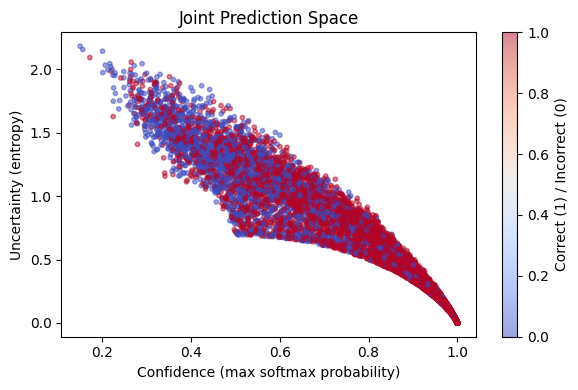

In [ ]:
# 그림이 거의 대각선 한 줄처럼 나오면, confidence와 entropy가 거의 같은 정보라는 뜻
# joint space가 collapse된다는 말의 시각적 근거
plt.figure(figsize=(6, 4))
plt.scatter(
    confidence, uncertainty, c=correct,
    cmap="coolwarm", alpha=0.5, s=10
)

plt.xlabel("Confidence (max softmax probability)")
plt.ylabel("Uncertainty (entropy)")
plt.title("Joint Prediction Space")
plt.colorbar(label="Correct (1) / Incorrect (0)")
plt.tight_layout()
plt.show()

In [10]:
corr = np.corrcoef(confidence, uncertainty)[0, 1]
print("Corr(confidence and entropy):", round(corr, 4))

Corr(confidence and entropy): -0.9654


In [15]:
correct_df = df[df["correct"] == 1]
incorrect_df = df[df["correct"] == 0]

print("Accuracy:", df["correct"].mean())
print("Num correct:", len(correct_df))
print("Num incorrect:", len(incorrect_df))

print("\nAverage confidence")
print("  Correct   :", round(correct_df["confidence"].mean(), 4))
print("  Incorrect :", round(incorrect_df["confidence"].mean(), 4))

print("\nAverage entropy")
print("  Correct   :", round(correct_df["uncertainty_entropy"].mean(), 4))
print("  Incorrect :", round(incorrect_df["uncertainty_entropy"].mean(), 4))

Accuracy: 0.7849
Num correct: 7849
Num incorrect: 2151

Average confidence
  Correct   : 0.8519
  Incorrect : 0.583

Average entropy
  Correct   : 0.4362
  Incorrect : 1.0637


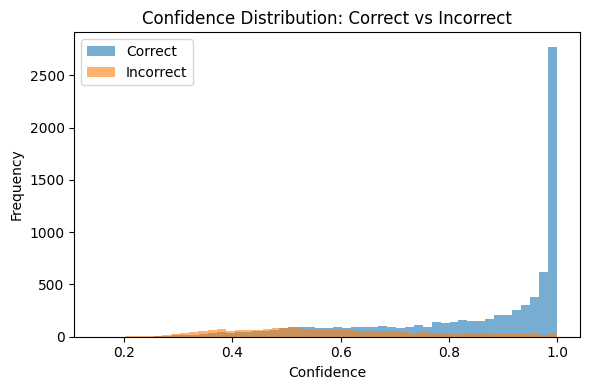

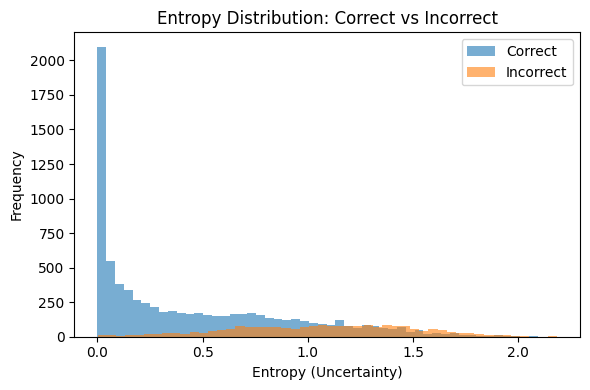

In [18]:
# confidence 분포
plt.figure(figsize=(6, 4))
plt.hist(correct_df["confidence"], bins=50, alpha=0.6, label="Correct")
plt.hist(incorrect_df["confidence"], bins=50, alpha=0.6, label="Incorrect")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

# entropy 분포
plt.figure(figsize=(6, 4))
plt.hist(correct_df["uncertainty_entropy"], bins=50, alpha=0.6, label="Correct")
plt.hist(incorrect_df["uncertainty_entropy"], bins=50, alpha=0.6, label="Incorrect")
plt.xlabel("Entropy (Uncertainty)")
plt.ylabel("Frequency")
plt.title("Entropy Distribution: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

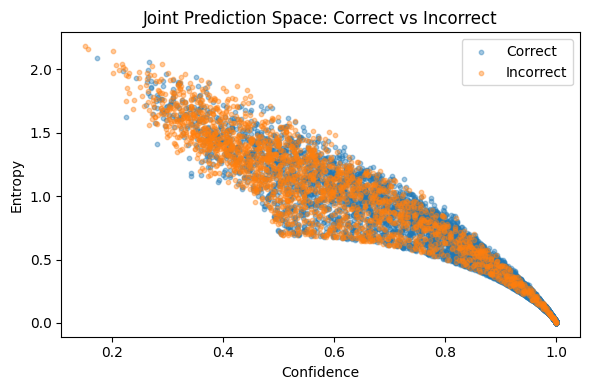

In [20]:
plt.figure(figsize=(6, 4))
plt.scatter(
    correct_df["confidence"],
    correct_df["uncertainty_entropy"],
    alpha=0.4,
    s=10,
    label="Correct"
)
plt.scatter(
    incorrect_df["confidence"],
    incorrect_df["uncertainty_entropy"],
    alpha=0.4,
    s=10,
    label="Incorrect"
)

plt.xlabel("Confidence")
plt.ylabel("Entropy")
plt.title("Joint Prediction Space: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

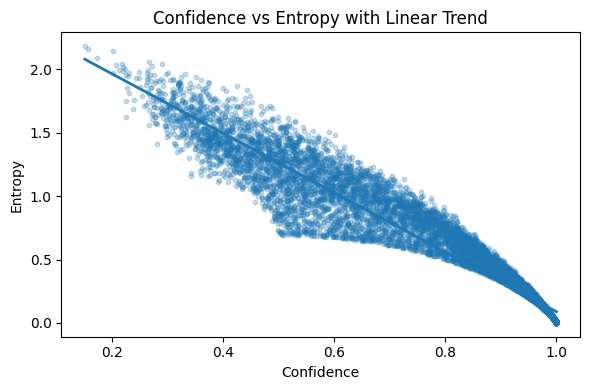

Linear fit: entropy = -2.3434 * confidence + 2.4321


In [22]:
z = np.polyfit(confidence, uncertainty, 1)
p = np.poly1d(z)

plt.figure(figsize=(6, 4))
plt.scatter(confidence, uncertainty, alpha=0.25, s=10)
plt.plot(
    np.sort(confidence),
    p(np.sort(confidence)),
    linewidth=2
)

plt.xlabel("Confidence")
plt.ylabel("Entropy")
plt.title("Confidence vs Entropy with Linear Trend")
plt.tight_layout()
plt.show()

print("Linear fit: entropy = {:.4f} * confidence + {:.4f}".format(z[0], z[1]))

In [ ]:
summary = pd.DataFrame({
    "group": ["all", "correct", "incorrect"],
    "count": [len(df), len(correct_df), len(incorrect_df)],
    "mean_confidence": [
        df["confidence"].mean(),
        correct_df["confidence"].mean(),
        incorrect_df["confidence"].mean()
    ],
    "mean_entropy": [
        df["uncertainty_entropy"].mean(),
        correct_df["uncertainty_entropy"].mean(),
        incorrect_df["uncertainty_entropy"].mean()
    ]
})

summary

# 모델 자체는 correct와 incorrect 상환에서 어느정도 자기 uncertainty를 반영하고 있음
# 모델이 틀릴 때 평균적으로 더 uncertainty가 높음 -> failure prediction 연구에서 기본 가정
# correct vs. incorrect는 평균적으로 분리됨. 그러나 평균만으로는 충분하지 않음

,group,count,mean_confidence,mean_entropy
0,all,10000,0.794093,0.571179
1,correct,7849,0.851932,0.436196
2,incorrect,2151,0.583040,1.063733


In [ ]:
# overconfidenct error 비율
overconfident_errors = df[
    (df["confidence"] > 0.9) &
    (df["correct"] == 0)
]

print(len(overconfident_errors))
print(len(overconfident_errors) / len(df))
# 전체 테스트 샘플 중 1.51%는 높은 confidence를 보였음에도 오답으로 분류되었으며, 이는 softmax 기반 confidence가 예측의 신뢰성을 완전히 대변하지 못함을 시사함

151
0.0151


In [27]:
# 4분면 분석
conf_thr = df["confidence"].median()
unc_thr = df["uncertainty_entropy"].median()

print("Confidence threshold (median):", round(conf_thr, 4))
print("Uncertainty threshold (median):", round(unc_thr, 4))

Confidence threshold (median): 0.8785
Uncertainty threshold (median): 0.4628


In [28]:
def assign_quadrant(row, conf_thr, unc_thr):
    high_conf = row["confidence"] >= conf_thr
    high_unc = row["uncertainty_entropy"] >= unc_thr

    if high_conf and not high_unc:
        return "HC_LU"   # High Confidence, Low Uncertainty
    elif high_conf and high_unc:
        return "HC_HU"   # High Confidence, High Uncertainty
    elif not high_conf and not high_unc:
        return "LC_LU"   # Low Confidence, Low Uncertainty
    else:
        return "LC_HU"   # Low Confidence, High Uncertainty
    
df["quadrant"] = df.apply(assign_quadrant, axis=1, conf_thr=conf_thr, unc_thr=unc_thr)
df[["confidence", "uncertainty_entropy", "correct", "quadrant"]].head()

,confidence,uncertainty_entropy,correct,quadrant
0,0.777627,0.577710,1,LC_HU
1,0.989463,0.059385,1,HC_LU
2,0.497098,0.916927,1,LC_HU
3,0.920033,0.403714,1,HC_LU
4,0.702481,0.821129,1,LC_HU


In [30]:
quadrant_summary = (
    df.groupby("quadrant")
      .agg(
          count=("correct", "size"),
          accuracy=("correct", "mean"),
          mean_confidence=("confidence", "mean"),
          mean_entropy=("uncertainty_entropy", "mean")
      )
      .reset_index()
)

quadrant_summary["error_rate"] = 1 - quadrant_summary["accuracy"]
quadrant_summary = quadrant_summary.sort_values("quadrant").reset_index(drop=True)
quadrant_summary["ratio"] = quadrant_summary["count"] / len(df)

quadrant_summary

,quadrant,count,accuracy,mean_confidence,mean_entropy,error_rate,ratio
0,HC_HU,111,0.909910,0.889180,0.495205,0.090090,0.0111
1,HC_LU,4889,0.963387,0.974467,0.119500,0.036613,0.4889
2,LC_HU,4889,0.602373,0.610051,1.027782,0.397627,0.4889
3,LC_LU,111,0.837838,0.860540,0.430332,0.162162,0.0111


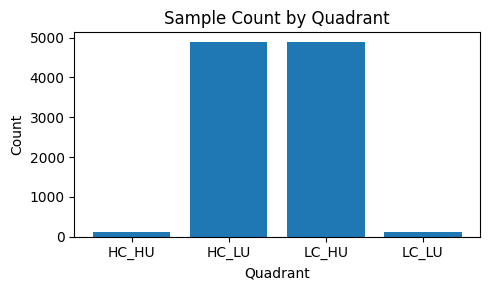

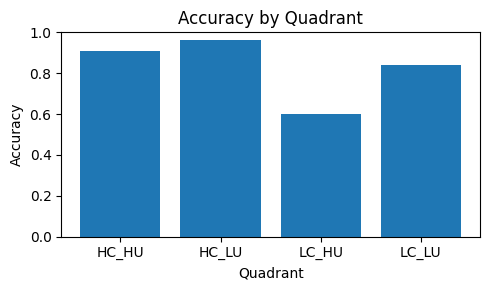

In [35]:
plt.figure(figsize=(5, 3))
plt.bar(quadrant_summary["quadrant"], quadrant_summary["count"])
plt.xlabel("Quadrant")
plt.ylabel("Count")
plt.title("Sample Count by Quadrant")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.bar(quadrant_summary["quadrant"], quadrant_summary["accuracy"])
plt.xlabel("Quadrant")
plt.ylabel("Accuracy")
plt.title("Accuracy by Quadrant")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

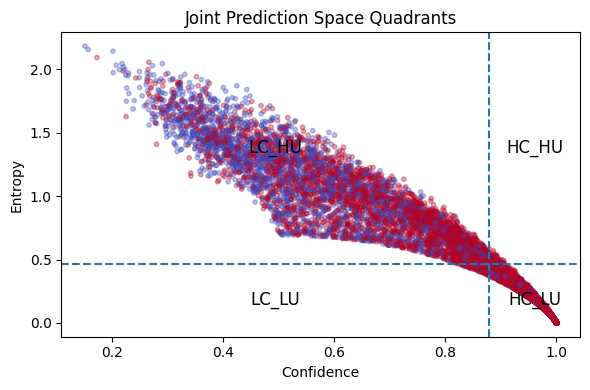

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df["confidence"],
    df["uncertainty_entropy"],
    c=df["correct"],
    cmap="coolwarm",
    alpha=0.35,
    s=10
)

plt.axvline(conf_thr, linestyle="--")
plt.axhline(unc_thr, linestyle="--")

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

plt.text((conf_thr + xmax) / 2, (ymin + unc_thr) / 2, "HC_LU", ha="center", va="center", fontsize=12)
plt.text((conf_thr + xmax) / 2, (unc_thr + ymax) / 2, "HC_HU", ha="center", va="center", fontsize=12)
plt.text((xmin + conf_thr) / 2, (ymin + unc_thr) / 2, "LC_LU", ha="center", va="center", fontsize=12)
plt.text((xmin + conf_thr) / 2, (unc_thr + ymax) / 2, "LC_HU", ha="center", va="center", fontsize=12)

plt.xlabel("Confidence")
plt.ylabel("Entropy")
plt.title("Joint Prediction Space Quadrants")
plt.tight_layout()
plt.show()

# softmax 기반 confidence와 entropy 기반 uncertainty는 joint prediction space를 구성하더라도 실질적으로는 제한된 구조만을 형성하며, 네 사분면을 고르게 활용하지 못함

In [ ]:
incorrect_df = df[df["correct"] == 0]
incorrect_quadrant_summary = (
    incorrect_df.groupby("quadrant")
    .size()
    .reset_index(name="incorrect_count")
)
incorrect_quadrant_summary["incorrect_ratio_within_errors"] = (
    incorrect_quadrant_summary["incorrect_count"] / len(incorrect_df)
)

incorrect_quadrant_summary
# softmax-confidence / entropy-uncertainty 기반 joint space 구성 하지만 공간 점유가 대각선 중심으로 붕괴
# 중간 두 사분면이 희소
# 따라서 richer predictive uncertainty 필요. MC Dropout 또는 ensemble 기반 joint space로 확장

,quadrant,incorrect_count,incorrect_ratio_within_errors
0,HC_HU,10,0.004649
1,HC_LU,179,0.083217
2,LC_HU,1944,0.903766
3,LC_LU,18,0.008368


In [42]:
overconfident_errors = df[
    (df["confidence"] > 0.9) &
    (df["correct"] == 0)
]

overconfident_errors[["confidence", "uncertainty_entropy", "quadrant"]].head()

,confidence,uncertainty_entropy,quadrant
24,0.979634,0.121721,HC_LU
76,0.967508,0.180783,HC_LU
139,0.940226,0.254286,HC_LU
247,0.982612,0.116432,HC_LU
249,0.977253,0.149954,HC_LU


In [ ]:
overconfident_quadrants = (
    overconfident_errors.groupby("quadrant")
    .size()
    .reset_index(name="count")
)

overconfident_quadrants["ratio"] = overconfident_quadrants["count"] / len(overconfident_errors)
overconfident_quadrants

# entropy 기반 uncertainty는 overconfident error를 구분하지 못함

,quadrant,count,ratio
0,HC_LU,151,1.0


### Bayesian